In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [5]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [ ]:
# Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True # batchnorm acts differently during training and testing so be careful
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []
# -----------------------------------------------------------------------------------------------
class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
    
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  def parameters(self):
    return [self.weight]
#-------------------------------------------------------------------------------------------------------
class Flatten:
  def __call__(self,x):
    self.out=x.view(x.shape[0],-1)
    return self.out
  def parameters(self):
    return []
#-------------------------------------------------------------------------------------------------
  
  # containers are way of organising layers 
  # sequential container just passes the values sequentially through layers
class Sequential:
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self,x):
    for layer in self.layers:
      x=layer(x)
    self.out=x
    return self.out
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()] # all parameters of child module

In [27]:
n_embd = 10 
n_hidden = 200 

g = torch.Generator().manual_seed(2147483647) 
# C = torch.randn((vocab_size, n_embd), generator=g)
# layers=[
#   Embedding(vocab_size,n_embd),
#   Flatten(),
#   Linear(n_embd*block_size , n_hidden,bias =False),
#   BatchNorm1d(n_hidden), 
#   Tanh(),
#   Linear(n_hidden,vocab_size)]
model = Sequential(
  [Embedding(vocab_size,n_embd),
  Flatten(),
  Linear(n_embd*block_size , n_hidden,bias =False),
  BatchNorm1d(n_hidden), 
  Tanh(),
  Linear(n_hidden,vocab_size)]
  )

with torch.no_grad():
  model.layers[-1].weight *=0.1 # making last layer less confident

# parameters= [p  for layer in layers for p in layer.parameters()]
parameters= model.parameters()
print(sum(p.nelement() for p in parameters)) 
for p in parameters:
  p.requires_grad = True

22097


In [34]:
max_steps=200000
batch_size=32
lossi=[]

for i in range (max_steps):

    # minibatch construct
    ix = torch.randint(0,Xtr.shape[0], (batch_size,) ) 
    Xb, Yb = Xtr[ix], Ytr[ix] 
    
    # forward pass
    # emb = C[Xb] # embedding made a layer for it above
    # x = emb.view(emb.shape[0],-1) # flattening made a layer above
    # x= Xb
    # for layer in layers:
    #     x=layer(x)
    logits= model(Xb)
    # loss=F.cross_entropy(x, Yb)
    loss=F.cross_entropy(logits, Yb)
            
    # backward pass
    for p in parameters:
        p.grad=None
    loss.backward()

    #update
    lr=0.1 if i <100000 else 0.01
    for p in parameters:
        p.data+= -lr*p.grad 
    
    # track stats:
    if i % 1000==0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item(): 4f}')
   
    lossi.append(loss.log10().item())
    # break
print(loss.item()) 


      0/ 200000:  3.266802
   1000/ 200000:  2.379908
   2000/ 200000:  2.443366
   3000/ 200000:  2.403654
   4000/ 200000:  2.124832
   5000/ 200000:  2.267199
   6000/ 200000:  2.035395
   7000/ 200000:  2.080110
   8000/ 200000:  2.045878
   9000/ 200000:  2.644824
  10000/ 200000:  1.855484
  11000/ 200000:  2.642543
  12000/ 200000:  1.793300
  13000/ 200000:  2.309166
  14000/ 200000:  2.233310
  15000/ 200000:  2.608337
  16000/ 200000:  1.982041
  17000/ 200000:  2.373621
  18000/ 200000:  2.107203
  19000/ 200000:  2.363199
  20000/ 200000:  2.227993
  21000/ 200000:  1.958908
  22000/ 200000:  1.724613
  23000/ 200000:  1.935949
  24000/ 200000:  2.179430
  25000/ 200000:  1.849089
  26000/ 200000:  1.743222
  27000/ 200000:  1.879079
  28000/ 200000:  1.739706
  29000/ 200000:  2.567956
  30000/ 200000:  1.835659
  31000/ 200000:  2.261323
  32000/ 200000:  2.013173
  33000/ 200000:  2.291585
  34000/ 200000:  1.923379
  35000/ 200000:  2.361544
  36000/ 200000:  2.106232
 

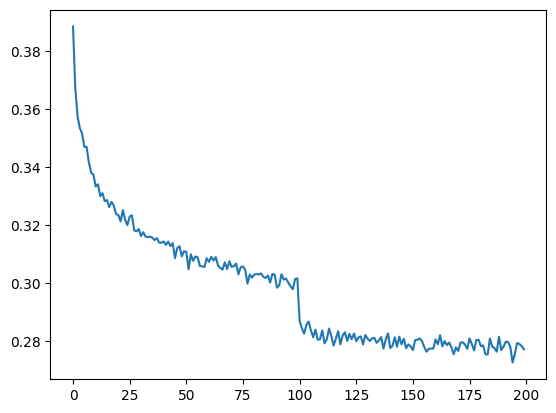

In [35]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [36]:
torch.manual_seed(42);

In [37]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [38]:
@torch.no_grad() # disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.909273624420166
val 2.04964017868042


In [39]:
# sample 

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

anuella.
tis.
marian.
danis.
naysia.
yannah.
mahel.
man.
ephaniah.
gianze.
kendrijo.
dregkson.
ranqonya.
becvi.
iser.
zalani.
carleigh.
darell.
chiel.
roselyn.
